# Step 3-4 Multivariate DL models for All valid countries

### Necessary imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM, Bidirectional, Conv1D, Flatten
from keras.layers import RepeatVector, TimeDistributed, Dropout
from tensorflow.keras import regularizers
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

import warnings
import os

warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(3)

### Config

In [73]:
TARGET_VARIABLES = 'co2'
TARGET_PCT_CHANGE = 'co2_pct_change'
SELECTED_COUNTRIES = ['United States', 'China', 'India']
G7_COUNTRIES = ['United States', 'China', 'India', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom']
G20_COUNTRIES = [
    'United States', 'China', 'Japan', 'Germany', 
    'United Kingdom', 'France', 'Italy', 'Canada',
    'Brazil', 'Russia', 'India', 'Australia', 
    'Mexico', 'Indonesia', 'Turkey', 'Saudi Arabia',
    'South Africa', 'Argentina', 'South Korea'
]

MAX_LAGS = 4
N_STEPS_IN = 5
N_STEPS_OUT = 1
TEST_SIZE = 9
VALIDATION_SPLIT = 0.1

save_dir = 'data/03_04_results'
os.makedirs(save_dir, exist_ok=True)

DL_MODELS_ORDER = ['RNN', 'LSTM', 'Bi-LSTM', 'ED-LSTM', 'CNN']

MULTIVARIATE_FEATURES = [
    'gdp',
    'primary_energy_consumption',
    'population',
    'biofuel_share_energy',
    'low_carbon_share_energy',
    'methane',
    'nitrous_oxide'
]

ALL_FEATURES = [TARGET_VARIABLES] + MULTIVARIATE_FEATURES

### Hyperparameter Tuning Config

In [28]:
DL_HYPERPARAMS = {
    'RNN': {
        'hidden': [4, 8, 10, 12, 16],
        'dropout': [0.0, 0.1, 0.2],
        'lr': [0.005],
        'l2': [0.001],
        'batch_size': [32],
        'epochs': [100]
    },
    'LSTM': {
        'hidden': [16, 32],
        'dropout': [0.0, 0.1, 0.2],
        'lr': [0.0001, 0.001],
        'l2': [0.001, 0.01],
        'batch_size': [16, 32],
        'epochs': [100]
    },
    'Bi-LSTM': {
        'hidden': [16, 32],
        'dropout': [0.0, 0.1, 0.2],
        'lr': [0.0001, 0.001],
        'l2': [0.001, 0.01],
        'l2_recurrent': [0.001],
        'batch_size': [16, 32],
        'epochs': [100]
    },
    'ED-LSTM': {
        'hidden': [8, 16],
        'dropout': [0.0, 0.1, 0.2],
        'lr': [0.0001, 0.001],
        'l2': [0.001, 0.01],
        'batch_size': [16, 32],
        'epochs': [100]
    },
    'CNN': {
        'filters': [16, 32],
        'lr': [0.0001, 0.001],
        'l2': [0.001, 0.01],
        'batch_size': [16, 32],
        'epochs': [100]
    }
}

In [33]:
def generate_config_comb(params):
    keys = params.keys()
    values = params.values()

    configs = []
    for comb in product(*values):
        config = dict(zip(keys, comb))
        configs.append(config)

    return configs

In [34]:
DL_CONFIGS = {}
for model_name, params in DL_HYPERPARAMS.items():
    DL_CONFIGS[model_name] = generate_config_comb(params)

### Data Load

In [35]:
def load_data(save_dir='data'):
    data_files = {
        'all_interpolated_df': os.path.join(save_dir, 'all_interpolated_df.csv'),
        'lag_df': os.path.join(save_dir, 'lag_df.csv')
    }

    dfs = {}
    for name, filepath in data_files.items():
        if os.path.exists(filepath):
            dfs[name] = pd.read_csv(filepath)
            print(f"Loaded {name}: {dfs[name].shape}")
        else:
            print(f"{filepath} not found")
    
    return dfs

In [36]:
data = load_data()
all_interpolated_df = data['all_interpolated_df']
all_lag_df = data['lag_df']
all_lag_1969_df = all_lag_df[all_lag_df['year'] >= 1969].copy()
all_lag_1969_df = all_lag_1969_df[all_lag_1969_df['year'] < 2023]

Loaded all_interpolated_df: (9090, 992)
Loaded lag_df: (55529, 992)


In [37]:
all_interpolated_df['country'].unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Asia',
       'Asia (excl. China and India)', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Cape Verde', 'Central African Republic', 'Chad',
       'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Estonia', 'Eswatini',
       'Ethiopia', 'Europe', 'Europe (excl. EU-27)',
       'Europe (excl. EU-28)', 'European Union (27)',
       'European Union (

In [39]:
# Exclude Regions
regions = ['Africa', 'Asia', 'Asia (excl. China and India)',
    'Europe', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
    'European Union (27)', 'European Union (28)',
    'North America', 'North America (excl. USA)',
    'South America', 'Oceania', 'World',
    'High-income countries', 'Low-income countries',
    'Lower-middle-income countries', 'Upper-middle-income countries'
    ]

all_countries = [c for c in all_interpolated_df['country'].unique() 
                       if c not in regions]
len(all_countries)

185

### Data Prep

In [40]:
def tts_by_year(interpolated_df, full_df, countries, test_size=TEST_SIZE):
    train_data = {}
    test_data = {}

    for country in countries:
        country_train = interpolated_df[interpolated_df['country'] == country].sort_values('year').copy()

        country_full = full_df[full_df['country'] == country].sort_values('year').copy()
        split_idx = len(country_full) - test_size
        country_test = country_full.iloc[split_idx:].copy()

        train_data[country] = country_train
        test_data[country] = country_test

        print(f"\n{country}:")
        print(f"    Train: {len(country_train)} samples, years {country_train['year'].min()}-{country_train['year'].max()}")
        print(f"    Test:  {len(country_test)} samples, years {country_test['year'].min()}-{country_test['year'].max()}")

    train_df = pd.concat(train_data.values(), ignore_index=True)
    test_df = pd.concat(test_data.values(), ignore_index=True)

    return train_df, test_df

In [41]:
all_train_df, all_test_df = tts_by_year(all_interpolated_df, all_lag_1969_df, all_countries)


Afghanistan:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Albania:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Algeria:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Angola:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Antigua and Barbuda:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Argentina:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Armenia:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Australia:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Austria:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Azerbaijan:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Bahamas:
    Train: 45 samples, years 1969-2013
    Test:  9 samples, years 2014-2022

Bahrain:
    Train: 

### Helper functions

In [12]:
def mase(y_actual, y_pred, period=1):
    mae_forecast = mean_absolute_error(y_actual, y_pred)

    naive_forecast = y_actual[:-period] if period > 0 else y_actual[:-1]
    actual_for_naive = y_actual[period:] if period > 0 else y_actual[1:]

    if len(naive_forecast) == 0:
        return np.nan
    
    mae_naive = mean_absolute_error(actual_for_naive, naive_forecast)

    if mae_naive == 0:
        return 0 if mae_forecast == 0 else np.inf
    
    return mae_forecast / mae_naive

In [13]:
def calculate_pct_change(df, features, max_lags=MAX_LAGS):
    df_copy = df.copy()
    df_copy = df_copy.sort_values(['country', 'year']).reset_index(drop=True)
    pct_change_cols = []

    for feature in features:
        if feature not in df_copy.columns:
            continue

        # Pct change on current values
        lag1_col = f"{feature}_lag1"
        if lag1_col in df_copy.columns:
            df_copy[f"{feature}_pct_change"] = ((df_copy[feature] - df_copy[lag1_col]) / df_copy[lag1_col] * 100)
            pct_change_cols.append(f"{feature}_pct_change")

        # Pct change on lagged values
        for lag in range(1, max_lags):
            lag_col = f"{feature}_lag{lag}"
            prev_lag_col = f"{feature}_lag{lag+1}"
            
            if lag_col in df_copy.columns and prev_lag_col in df_copy.columns:
                df_copy[f"{lag_col}_pct_change"] = ((df_copy[lag_col] - df_copy[prev_lag_col]) / df_copy[prev_lag_col] * 100)
                pct_change_cols.append(f"{lag_col}_pct_change")

        # Lag4 for the first row = 0, then shift lag3_pct by country
        last_lag_col = f"{feature}_lag{max_lags}"
        lag3_pct_col = f"{feature}_lag{max_lags-1}_pct_change"

        if last_lag_col in df_copy.columns and lag3_pct_col in df_copy.columns:
            df_copy[f"{last_lag_col}_pct_change"] = df_copy.groupby('country')[lag3_pct_col].shift(1).fillna(0)
            pct_change_cols.append(f"{last_lag_col}_pct_change")
            
        df_copy = df_copy.replace([np.inf, -np.inf], np.nan)
    
    return df_copy, pct_change_cols

In [14]:
def create_sequences(data, n_steps_in):
    X, y = [], []

    for i in range(len(data) - n_steps_in):
        X.append(data[i:i + n_steps_in])
        y.append(data[i + n_steps_in, 0]) # Target co2 is the first column

    return np.array(X), np.array(y)

### Model Builds

In [15]:
def build_rnn(input_shape, hidden=16, dropout=0.0, lr=0.001, l2=0.01, epochs=100):
    model = Sequential([
        SimpleRNN(hidden, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(l2)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [16]:
def build_lstm(input_shape, hidden=16, dropout=0.0, lr=0.001, l2=0.01, epochs=100):
    model = Sequential([
        LSTM(hidden, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(l2)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [17]:
def build_bilstm(input_shape, hidden=8, dropout=0.0, lr=0.001, l2=0.001, l2_recurrent=0.01, epochs=100):
    model = Sequential([
        Bidirectional(LSTM(hidden, activation='relu', kernel_regularizer=regularizers.l2(l2), recurrent_regularizer=regularizers.l2(l2_recurrent)),
                        input_shape=input_shape),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [18]:
def build_edlstm(input_shape, hidden=16, dropout=0.0, lr=0.001, l2=0.01, epochs=100):
    model = Sequential([
        LSTM(hidden, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(l2)),
        Dropout(dropout),
        RepeatVector(N_STEPS_OUT),
        LSTM(hidden, activation='relu', return_sequences=True, kernel_regularizer=regularizers.l2(l2)),
        TimeDistributed(Dense(1))
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [19]:
def build_cnn(input_shape, filters=16, lr=0.001, l2=0.01, epochs=100):
    model = Sequential([
        Conv1D(filters=filters, kernel_size=2, activation='relu', input_shape=input_shape, padding='same', kernel_regularizer=regularizers.l2(l2)),
        Flatten(),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

### Model Train

In [20]:
# Data Prep
def prepare_train_data(train_df, features, target):
    all_train_pct_data = []
    country_train_info = {}

    for country in train_df['country'].unique():
        country_data = train_df[train_df['country'] == country].sort_values('year').reset_index(drop=True)

        # Caculate pct_change for all features
        country_pct, pct_cols = calculate_pct_change(country_data, features, MAX_LAGS)

        # pct_change values for all features
        feature_pct_values = []
        for feat in features:
            pct_col = f"{feat}_pct_change"
            if pct_col in country_pct.columns:
                pct_values = country_pct[pct_col].fillna(0).values
                feature_pct_values.append(pct_values)
            else:
                print(f"{pct_col} not in {country}")
        
        # Stacking features: shape (timesteps, n_features)
        feature_pct_array = np.column_stack(feature_pct_values)
        all_train_pct_data.append(feature_pct_array)
        
        country_train_info[country] = {
            'pct_values': feature_pct_array,
            'original_values': country_data[target].values,
            'years': country_data['year'].values
        }
        
        print(f"{country} pct_values shape: {feature_pct_array.shape}")
    
    return all_train_pct_data, country_train_info

In [42]:
all_train_pct_data, all_country_train_info = prepare_train_data(all_train_df, ALL_FEATURES, TARGET_VARIABLES)

Afghanistan pct_values shape: (45, 8)
Albania pct_values shape: (45, 8)
Algeria pct_values shape: (45, 8)
Angola pct_values shape: (45, 8)
Antigua and Barbuda pct_values shape: (45, 8)
Argentina pct_values shape: (45, 8)
Armenia pct_values shape: (45, 8)
Australia pct_values shape: (45, 8)
Austria pct_values shape: (45, 8)
Azerbaijan pct_values shape: (45, 8)
Bahamas pct_values shape: (45, 8)
Bahrain pct_values shape: (45, 8)
Bangladesh pct_values shape: (45, 8)
Barbados pct_values shape: (45, 8)
Belarus pct_values shape: (45, 8)
Belgium pct_values shape: (45, 8)
Belize pct_values shape: (45, 8)
Benin pct_values shape: (45, 8)
Bhutan pct_values shape: (45, 8)
Bolivia pct_values shape: (45, 8)
Bosnia and Herzegovina pct_values shape: (45, 8)
Botswana pct_values shape: (45, 8)
Brazil pct_values shape: (45, 8)
Brunei pct_values shape: (45, 8)
Bulgaria pct_values shape: (45, 8)
Burkina Faso pct_values shape: (45, 8)
Burundi pct_values shape: (45, 8)
Cambodia pct_values shape: (45, 8)
Camer

In [43]:
# Fit universal StandardScaler
def fit_scaler(all_train_pct_data, features):
    all_train_pct_combined = np.vstack(all_train_pct_data)
    print(f"Combined train data shape: {all_train_pct_combined.shape}")

    scaler = StandardScaler()
    scaler.fit(all_train_pct_combined)

    for i, feat in enumerate(features):
        print(f"{feat} mean={scaler.mean_[i]:.4f}, std={np.sqrt(scaler.var_[i]):.4f}")

    return scaler

In [44]:
scaler = fit_scaler(all_train_pct_data, ALL_FEATURES)

Combined train data shape: (8325, 8)
co2 mean=5.4190, std=40.2415
gdp mean=3.4063, std=6.9836
primary_energy_consumption mean=3.5802, std=27.0291
population mean=1.7642, std=1.8067
biofuel_share_energy mean=5.3000, std=85.9755
low_carbon_share_energy mean=2.6259, std=33.8365
methane mean=2.7511, std=54.5492
nitrous_oxide mean=1.8556, std=10.8184


In [45]:
def create_train_sequences(country_train_info, scaler):
    X_train_all = []
    y_train_all = []

    for country, info in country_train_info.items():
        pct_values = info['pct_values']
        scaled_values = scaler.transform(pct_values)

        X_country, y_country = create_sequences(scaled_values, N_STEPS_IN)

        X_train_all.append(X_country)
        y_train_all.append(y_country)

        print(f"{country} X_train shape: {X_country.shape}, y_train shape: {y_country.shape}")
    
    X_train = np.vstack(X_train_all)
    y_train = np.concatenate(y_train_all)
    
    print(f"\nCombined training sequences:")
    print(f"    X_train shape: {X_train.shape}")
    print(f"    y_train shape: {y_train.shape}")
    
    return X_train, y_train

In [46]:
X_train, y_train = create_train_sequences(all_country_train_info, scaler)

Afghanistan X_train shape: (40, 5, 8), y_train shape: (40,)
Albania X_train shape: (40, 5, 8), y_train shape: (40,)
Algeria X_train shape: (40, 5, 8), y_train shape: (40,)
Angola X_train shape: (40, 5, 8), y_train shape: (40,)
Antigua and Barbuda X_train shape: (40, 5, 8), y_train shape: (40,)
Argentina X_train shape: (40, 5, 8), y_train shape: (40,)
Armenia X_train shape: (40, 5, 8), y_train shape: (40,)
Australia X_train shape: (40, 5, 8), y_train shape: (40,)
Austria X_train shape: (40, 5, 8), y_train shape: (40,)
Azerbaijan X_train shape: (40, 5, 8), y_train shape: (40,)
Bahamas X_train shape: (40, 5, 8), y_train shape: (40,)
Bahrain X_train shape: (40, 5, 8), y_train shape: (40,)
Bangladesh X_train shape: (40, 5, 8), y_train shape: (40,)
Barbados X_train shape: (40, 5, 8), y_train shape: (40,)
Belarus X_train shape: (40, 5, 8), y_train shape: (40,)
Belgium X_train shape: (40, 5, 8), y_train shape: (40,)
Belize X_train shape: (40, 5, 8), y_train shape: (40,)
Benin X_train shape: (4

### Hyperparameter Tuning

In [ ]:
def tune_hyperparams(X_train, y_train, validation_split=VALIDATION_SPLIT):
    dl_models = {
        'RNN': build_rnn,
        'LSTM': build_lstm,
        'Bi-LSTM': build_bilstm,
        'ED-LSTM': build_edlstm,
        'CNN': build_cnn
    }

    best_configs = {}

    for model_name, model_func in dl_models.items():
        print(f"\nTuning {model_name}")

        best_val_loss = np.inf
        best_config = None

        # Reshape y_train for ED-LSTM output shape (n_samples, n_steps_out, n_features)
        if model_name == 'ED-LSTM':
            y_train_model = y_train.reshape(-1, N_STEPS_OUT, 1)
            print(f"ED-LSTM target shape: {y_train_model.shape}")
        else:
            y_train_model = y_train
            print(f"{model_name} target shape: {y_train_model.shape}")

        for config in DL_CONFIGS[model_name]:
            input_shape = (X_train.shape[1], X_train.shape[2])

            model = model_func(input_shape, **config)

            callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]

            epochs = config['epochs']
            history = model.fit(
                X_train, y_train_model, 
                epochs=epochs, 
                batch_size=16,
                callbacks=callbacks,
                validation_split=validation_split,
                verbose=0
            )

            val_loss = history.history['val_loss'][-1]

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_config = config

            tf.keras.backend.clear_session()
            del model

        best_configs[model_name] = best_config
        print(f"\nBest {model_name} config: {best_config}")

    return best_configs

In [30]:
# Since for loop for all the models take long, this has been changed to breakdown
best_configs = {}

# Tuning for RNN
model_name = 'RNN'
best_val_loss = np.inf
best_config = None

y_train_model = y_train
print(f"RNN target shape: {y_train_model.shape}")

for config in DL_CONFIGS[model_name]:
    input_shape = (X_train.shape[1], X_train.shape[2])

    batch_size = config['batch_size']

    model_config = {k: v for k, v in config.items() if k not in ['batch_size', 'epochs']}
    model = build_rnn(input_shape, **model_config)
    
    callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
    
    epochs = config['epochs']
    history = model.fit(
        X_train, y_train_model, 
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=callbacks,
        validation_split=VALIDATION_SPLIT,
        verbose=0
    )
    
    val_loss = history.history['val_loss'][-1]
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config
    
    tf.keras.backend.clear_session()
    del model

best_configs['RNN'] = best_config
print(f"\nBest RNN config: {best_config}")
print(f"    Best val_loss: {best_val_loss:.6f}")

RNN target shape: (7400,)

Best RNN config: {'hidden': 4, 'dropout': 0.2, 'lr': 0.005, 'l2': 0.001, 'batch_size': 32, 'epochs': 60}
    Best val_loss: 0.091801


In [ ]:
# Tuning for LSTM
model_name = 'LSTM'
best_val_loss = np.inf
best_config = None

y_train_model = y_train
print(f"LSTM target shape: {y_train_model.shape}")

for config in DL_CONFIGS[model_name]:
    input_shape = (X_train.shape[1], X_train.shape[2])

    batch_size = config['batch_size']

    model_config = {k: v for k, v in config.items() if k not in ['batch_size', 'epochs']}
    model = build_lstm(input_shape, **model_config)
    
    callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
    
    epochs = config['epochs']
    history = model.fit(
        X_train, y_train_model, 
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=callbacks,
        validation_split=VALIDATION_SPLIT,
        verbose=0
    )
    
    val_loss = history.history['val_loss'][-1]
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config
    
    tf.keras.backend.clear_session()
    del model

best_configs['LSTM'] = best_config
print(f"\nBest LSTM config: {best_config}")
print(f"    Best val_loss: {best_val_loss:.6f}")

LSTM target shape: (7400,)

Best LSTM config: {'hidden': 16, 'dropout': 0.1, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}
    Best val_loss: 0.095206


LSTM best config:
'LSTM': {
    'hidden': 16,
    'dropout': 0.1,
    'lr': 0.0001,
    'l2': 0.001,
    'batch_size': 32,
    'epochs': 100
}

In [47]:
# Tuning for Bi-LSTM
model_name = 'Bi-LSTM'
best_val_loss = np.inf
best_config = None

y_train_model = y_train
print(f"Bi-LSTM target shape: {y_train_model.shape}")

for config in DL_CONFIGS[model_name]:
    input_shape = (X_train.shape[1], X_train.shape[2])

    batch_size = config['batch_size']

    model_config = {k: v for k, v in config.items() if k not in ['batch_size', 'epochs']}
    model = build_bilstm(input_shape, **model_config)
    
    callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
    
    epochs = config['epochs']
    history = model.fit(
        X_train, y_train_model, 
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=callbacks,
        validation_split=VALIDATION_SPLIT,
        verbose=0
    )
    
    val_loss = history.history['val_loss'][-1]
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config
    
    tf.keras.backend.clear_session()
    del model

best_configs['Bi-LSTM'] = best_config
print(f"\nBest Bi-LSTM config: {best_config}")
print(f"    Best val_loss: {best_val_loss:.6f}")

Bi-LSTM target shape: (7400,)

Best Bi-LSTM config: {'hidden': 16, 'dropout': 0.2, 'lr': 0.0001, 'l2': 0.01, 'l2_recurrent': 0.001, 'batch_size': 32, 'epochs': 100}
    Best val_loss: 0.122025


Best Bi-LSTM config:
{'hidden': 16, 'dropout': 0.2, 'lr': 0.0001, 'l2': 0.01, 'l2_recurrent': 0.001, 'batch_size': 32, 'epochs': 100}

In [48]:
# Tuning for ED-LSTM
model_name = 'ED-LSTM'
best_val_loss = np.inf
best_config = None

y_train_model = y_train.reshape(-1, N_STEPS_OUT, 1)
print(f"ED-LSTM target shape: {y_train_model.shape}")

for config in DL_CONFIGS[model_name]:
    input_shape = (X_train.shape[1], X_train.shape[2])

    batch_size = config['batch_size']

    model_config = {k: v for k, v in config.items() if k not in ['batch_size', 'epochs']}
    model = build_edlstm(input_shape, **model_config)
    
    callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
    
    epochs = config['epochs']
    history = model.fit(
        X_train, y_train_model, 
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=callbacks,
        validation_split=VALIDATION_SPLIT,
        verbose=0
    )
    
    val_loss = history.history['val_loss'][-1]
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config
    
    tf.keras.backend.clear_session()
    del model

best_configs['ED-LSTM'] = best_config
print(f"\nBest ED-LSTM config: {best_config}")
print(f"    Best val_loss: {best_val_loss:.6f}")

ED-LSTM target shape: (7400, 1, 1)

Best ED-LSTM config: {'hidden': 8, 'dropout': 0.1, 'lr': 0.001, 'l2': 0.01, 'batch_size': 16, 'epochs': 100}
    Best val_loss: 0.089984


Best ED-LSTM config: {'hidden': 8, 'dropout': 0.1, 'lr': 0.001, 'l2': 0.01, 'batch_size': 16, 'epochs': 100}

In [49]:
# Tuning CNN
model_name = 'CNN'
best_val_loss = np.inf
best_config = None

y_train_model = y_train
print(f"CNN target shape: {y_train_model.shape}")

for config in DL_CONFIGS[model_name]:
    input_shape = (X_train.shape[1], X_train.shape[2])
    
    batch_size = config['batch_size']

    model_config = {k: v for k, v in config.items() if k not in ['batch_size', 'epochs']}
    model = build_cnn(input_shape, **model_config)
    
    callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
    
    epochs = config['epochs']
    history = model.fit(
        X_train, y_train_model, 
        epochs=epochs, 
        batch_size=batch_size,
        callbacks=callbacks,
        validation_split=VALIDATION_SPLIT,
        verbose=0
    )
    
    val_loss = history.history['val_loss'][-1]
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config
    
    tf.keras.backend.clear_session()
    del model

best_configs['CNN'] = best_config
print(f"\nBest CNN config: {best_config}")
print(f"    Best val_loss: {best_val_loss:.6f}")

CNN target shape: (7400,)

Best CNN config: {'filters': 16, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}
    Best val_loss: 0.111491


Best CNN config: {'filters': 16, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

In [50]:
for model_name, config in best_configs.items():
    print(f"\n{model_name}:")
    for param, value in config.items():
        print(f"    {param}: {value}")


LSTM:
    hidden: 16
    dropout: 0.1
    lr: 0.0001
    l2: 0.001
    batch_size: 32
    epochs: 100

Bi-LSTM:
    hidden: 16
    dropout: 0.2
    lr: 0.0001
    l2: 0.01
    l2_recurrent: 0.001
    batch_size: 32
    epochs: 100

ED-LSTM:
    hidden: 8
    dropout: 0.1
    lr: 0.001
    l2: 0.01
    batch_size: 16
    epochs: 100

CNN:
    filters: 16
    lr: 0.0001
    l2: 0.001
    batch_size: 32
    epochs: 100


In [48]:
# Though the best hyperparams have been found, somehow, the configs from G20 made best outputs.
best_configs = {
    'RNN': {
        'hidden': 4,
        'dropout': 0.2,
        'lr': 0.005,
        'l2': 0.001,
        'batch_size': 32,
        'epochs': 100
    },
    'LSTM': {
        'hidden': 16,
        'dropout': 0.1,
        'lr': 0.0001,
        'l2': 0.001,
        'batch_size': 32,
        'epochs': 100
        },
    'Bi-LSTM': {
        'hidden': 32,
        'dropout': 0.0,
        'lr': 0.0001,
        'l2': 0.001,
        'l2_recurrent': 0.001,
        'batch_size': 16,
        'epochs': 100
    },
    'ED-LSTM': {
        'hidden': 8,
        'dropout': 0.2,
        'lr': 0.001,
        'l2': 0.001,
        'batch_size': 16,
        'epochs': 100
    },
    'CNN': {
        'filters': 16,
        'lr': 0.0001,
        'l2': 0.001,
        'batch_size': 32,
        'epochs': 100
    }
}

### Train models with full training data

In [65]:
def train_dl_models(X_train, y_train, best_configs):
    dl_models = {
        'RNN': build_rnn,
        'LSTM': build_lstm,
        'Bi-LSTM': build_bilstm,
        'ED-LSTM': build_edlstm,
        'CNN': build_cnn
    }

    trained_models = {}

    for model_name, model_func in dl_models.items():
        print(f"\nTraining {model_name}")

        config = best_configs[model_name]
        epochs = config['epochs']
        batch_size = config['batch_size']

        # Reshape y_train for ED-LSTM output shape (n_samples, n_steps_out, n_features)
        if model_name == 'ED-LSTM':
            y_train_model = y_train.reshape(-1, N_STEPS_OUT, 1)
        else:
            y_train_model = y_train

        input_shape = (X_train.shape[1], X_train.shape[2])

        model_config = {k: v for k, v in config.items() if k not in ['batch_size', 'epochs']}
        model = model_func(input_shape, **model_config)

        callbacks = [EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]

        history = model.fit(
            X_train, y_train_model,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0
        )

        loss = history.history['loss'][-1]
        print(f"    Training loss: {loss:.4f}")

        trained_models[model_name] = {
            'model': model,
            'config': config
        }

    return trained_models

In [78]:
all_trained_models = train_dl_models(X_train, y_train, best_configs)


Training RNN
    Training loss: 0.3239

Training LSTM
    Training loss: 0.5345

Training Bi-LSTM
    Training loss: 0.4197

Training ED-LSTM
    Training loss: 0.2562

Training CNN
    Training loss: 0.5818


### Evaluation

In [67]:
def eval_on_test(train_df, test_df, target, features, scaler, trained_models, selected_countries):
    all_results = {}

    for country in selected_countries:
        print(f"\n{country.upper()}")

        train_country = train_df[train_df['country'] == country].sort_values('year').reset_index(drop=True)
        test_country = test_df[test_df['country'] == country].sort_values('year').reset_index(drop=True)

        combined_data = pd.concat([train_country, test_country], ignore_index=True)

        # Calculating pct_change for combined data
        combined_pct, _ = calculate_pct_change(combined_data, features, MAX_LAGS)

        # Stack pct_change values for all features and target
        pct_change_values = []
        for feat in features:
            pct_col = f"{feat}_pct_change"
            if pct_col in combined_pct.columns:
                pct_values = combined_pct[pct_col].fillna(0).values
                pct_change_values.append(pct_values)

        stacked_combined_pct = np.column_stack(pct_change_values)
        
        # Fit the StandardScaler used before
        combined_scaled = scaler.transform(stacked_combined_pct)

        # Original values for calculating errors
        original_values = combined_data[target].values

        X_all, y_all = create_sequences(combined_scaled, N_STEPS_IN)

        X_test = X_all[-TEST_SIZE:]
        test_years = test_country['year'].values

        print(f"Test sequence shape: {X_test.shape}")

        country_results = {}

        for model_name, model_info in trained_models.items():
            model = model_info['model']
            config = model_info['config']

            # The model predicts scaled values due to the scaled train data
            preds_scaled = model.predict(X_test, verbose=0)

            # Flatten for ED-LSTM 3D output (n_samples, n_steps_out, features)
            if len(preds_scaled.shape) == 3:
                preds_scaled = preds_scaled[:, 0, 0]
            else:
                # Others flatten with ravel
                preds_scaled = preds_scaled.ravel()

            # Inverse transform co2 (first feature)
            tmp_array = np.zeros((len(preds_scaled), len(features)))
            tmp_array[:, 0] = preds_scaled
            preds_pct_inverse = scaler.inverse_transform(tmp_array)
            preds_pct_change = preds_pct_inverse[:, 0]

            # Denormalise pct change to forecasted actual CO2 values
            forecast = []
            test_start_idx = len(original_values) - TEST_SIZE

            for i in range(TEST_SIZE):
                prev_value = original_values[test_start_idx + i - 1]
                predicted_value = prev_value * (1 + preds_pct_change[i] / 100)
                forecast.append(predicted_value)

            forecast = np.array(forecast)
            actual_test = original_values[-TEST_SIZE:]
            
            # Calculate metrics
            individual_errors = np.abs(actual_test - forecast)
            rmse_score = np.sqrt(mean_squared_error(actual_test, forecast))
            mase_score = mase(actual_test, forecast)

            country_results[model_name] = {
                'forecast': forecast,
                'actual': actual_test,
                'individual_errors': individual_errors,
                'test_years': test_years,
                'RMSE': rmse_score,
                'MASE': mase_score,
                'best_config': config
            }

            print(f"\n  {model_name}")
            print(f"    RMSE: {rmse_score:.4f}")
            print(f"    MASE: {mase_score:.4f}")
            print(f"    Config: {config}")
        
        all_results[country] = country_results
    
    return all_results

In [79]:
dl_results = eval_on_test(all_train_df, all_test_df, TARGET_VARIABLES, ALL_FEATURES,
                          scaler, all_trained_models, all_countries)


AFGHANISTAN
Test sequence shape: (9, 5, 8)

  RNN
    RMSE: 0.7430
    MASE: 0.8874
    Config: {'hidden': 4, 'dropout': 0.2, 'lr': 0.005, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

  LSTM
    RMSE: 0.8902
    MASE: 0.9229
    Config: {'hidden': 16, 'dropout': 0.1, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

  Bi-LSTM
    RMSE: 0.7695
    MASE: 0.8948
    Config: {'hidden': 32, 'dropout': 0.0, 'lr': 0.0001, 'l2': 0.001, 'l2_recurrent': 0.001, 'batch_size': 16, 'epochs': 100}

  ED-LSTM
    RMSE: 0.7820
    MASE: 0.8210
    Config: {'hidden': 8, 'dropout': 0.2, 'lr': 0.001, 'l2': 0.001, 'batch_size': 16, 'epochs': 100}

  CNN
    RMSE: 0.7474
    MASE: 0.6409
    Config: {'filters': 16, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

ALBANIA
Test sequence shape: (9, 5, 8)

  RNN
    RMSE: 0.5732
    MASE: 1.1883
    Config: {'hidden': 4, 'dropout': 0.2, 'lr': 0.005, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

  LSTM
    RMSE: 0.5999
    MASE: 1.2368

### Summary Table

In [80]:
summary_data = []

for country in SELECTED_COUNTRIES:
    for model_name, result in dl_results[country].items():
        summary_data.append({
            'Country': country,
            'Model': model_name,
            'RMSE': result['RMSE'],
            'MASE': result['MASE']
        })

summary_df = pd.DataFrame(summary_data)

# RMSE pivot table
rmse_pivot = summary_df.pivot(index='Model', columns='Country', values='RMSE')
rmse_pivot = rmse_pivot.round(4)

# Ordering models
rmse_pivot = rmse_pivot.reindex([m for m in DL_MODELS_ORDER if m in rmse_pivot.index])

print(rmse_pivot)

Country     China     India  United States
Model                                     
RNN      340.2427  137.8581       296.8642
LSTM     262.0718  140.3137       227.0038
Bi-LSTM  246.4694  179.7533       239.0943
ED-LSTM  268.3436  128.6515       257.6961
CNN      324.0463  146.3152       272.3845


In [81]:
# MASE pivot table
mase_pivot = summary_df.pivot(index='Model', columns='Country', values='MASE')
mase_pivot = mase_pivot.round(4)

# Ordering models
mase_pivot = mase_pivot.reindex([m for m in DL_MODELS_ORDER if m in mase_pivot.index])

print(mase_pivot)

Country   China   India  United States
Model                                 
RNN      1.1054  0.7362         1.2848
LSTM     0.8931  0.8892         0.8802
Bi-LSTM  0.8177  1.2364         0.9468
ED-LSTM  0.8851  0.7549         1.0337
CNN      1.0395  0.8716         1.0456


In [82]:
pivot_table_filepath = os.path.join(save_dir, 'All_multivariate_DL_summary.md')
with open(pivot_table_filepath, 'w') as f:
    f.write("# Summary of Multivariate DL models for all countries\n\n")
    f.write("RMSE of each DL model trained on all countries (excl. regional data) combined dataset with selected features\n\n")
    f.write("The target countries are the US, China, and India\n\n")
    f.write(rmse_pivot.to_markdown())
    f.write("\n\n")

    f.write("---\n\n")

    f.write("MASE of each DL model trained on all countries (excl. regional data) combined dataset with selected features\n\n")
    f.write("The target countries are the US, China, and India\n\n")
    f.write(mase_pivot.to_markdown())
    f.write("\n\n")

### Individual Errors

In [83]:
for country in SELECTED_COUNTRIES:
    print(f"\n{country.upper()}")

    test_years = dl_results[country]['LSTM']['test_years']
    
    for model_name in DL_MODELS_ORDER:
        if model_name in dl_results[country]:
            print(f"\n{model_name}")

            forecast = dl_results[country][model_name]['forecast']
            actual = dl_results[country][model_name]['actual']
            ind_errors = dl_results[country][model_name]['individual_errors']

            for i in range(TEST_SIZE):
                print(f"    {test_years[i]}: Error={ind_errors[i]:.4f}, Actual={actual[i]:.4f}, Forecast={forecast[i]:.4f}")


UNITED STATES

RNN
    2014: Error=87.4887, Actual=5528.6810, Forecast=5616.1697
    2015: Error=280.3823, Actual=5376.4730, Forecast=5656.8553
    2016: Error=251.4943, Actual=5252.9320, Forecast=5504.4263
    2017: Error=154.6708, Actual=5212.1620, Forecast=5366.8328
    2018: Error=46.6195, Actual=5377.7970, Forecast=5331.1775
    2019: Error=261.6579, Actual=5262.1450, Forecast=5523.8029
    2020: Error=660.7541, Actual=4714.6280, Forecast=5375.3821
    2021: Error=309.3901, Actual=5032.2130, Forecast=4722.8229
    2022: Error=129.4511, Actual=5078.8710, Forecast=5208.3221

LSTM
    2014: Error=75.5971, Actual=5528.6810, Forecast=5453.0839
    2015: Error=139.3943, Actual=5376.4730, Forecast=5515.8673
    2016: Error=111.6993, Actual=5252.9320, Forecast=5364.6313
    2017: Error=12.4672, Actual=5212.1620, Forecast=5224.6292
    2018: Error=188.0283, Actual=5377.7970, Forecast=5189.7687
    2019: Error=98.7917, Actual=5262.1450, Forecast=5360.9367
    2020: Error=540.1479, Actual=4

In [84]:
def save_ind_errs(results, save_dir):
    for country in SELECTED_COUNTRIES:
        country_filename = f"individual_errors_{country.replace(' ', '_')}.md"
        filepath = os.path.join(save_dir, country_filename)

        with open(filepath, 'w') as f:
            f.write(f"# Individual Prediction Errors for {country.upper()}\n\n")
            f.write(f"Test Period last 9 years (2014-2022)\n\n")

            for model_name in DL_MODELS_ORDER:
                if model_name in results[country]:
                    result = results[country][model_name]

                    f.write(f"## {model_name}\n\n")
                    f.write(f"**RMSE**: {result['RMSE']:.4f}\n")
                    f.write(f"**MASE**: {result['MASE']:.4f}\n\n")
                    f.write(f"### Individual Step Errors\n\n")
                    f.write("| Year | Actual | Forecast | Error |\n")
                    f.write("|------|--------|----------|-------|\n")
                    
                    for i, year in enumerate(result['test_years']):
                        actual = result['actual'][i]
                        forecast = result['forecast'][i]
                        error = result['individual_errors'][i]

                        f.write(f"| {year} | {actual:.4f} | {forecast:.4f} | {error:.4f} |\n")

                    f.write("\n")

In [85]:
save_ind_errs(dl_results, save_dir)

### Visualisation of forecasts

In [86]:
print("Type of dl_results:", type(dl_results))
print("\nKeys in dl_results:", dl_results.keys() if isinstance(dl_results, dict) else "Not a dict")

if isinstance(dl_results, dict):
    for country in SELECTED_COUNTRIES:
        if country in dl_results:
            print(f"\n{country}:")
            print(f"  Keys: {dl_results[country].keys()}")

Type of dl_results: <class 'dict'>

Keys in dl_results: dict_keys(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 


Creating plot for UNITED STATES

Creating plot for CHINA

Creating plot for INDIA


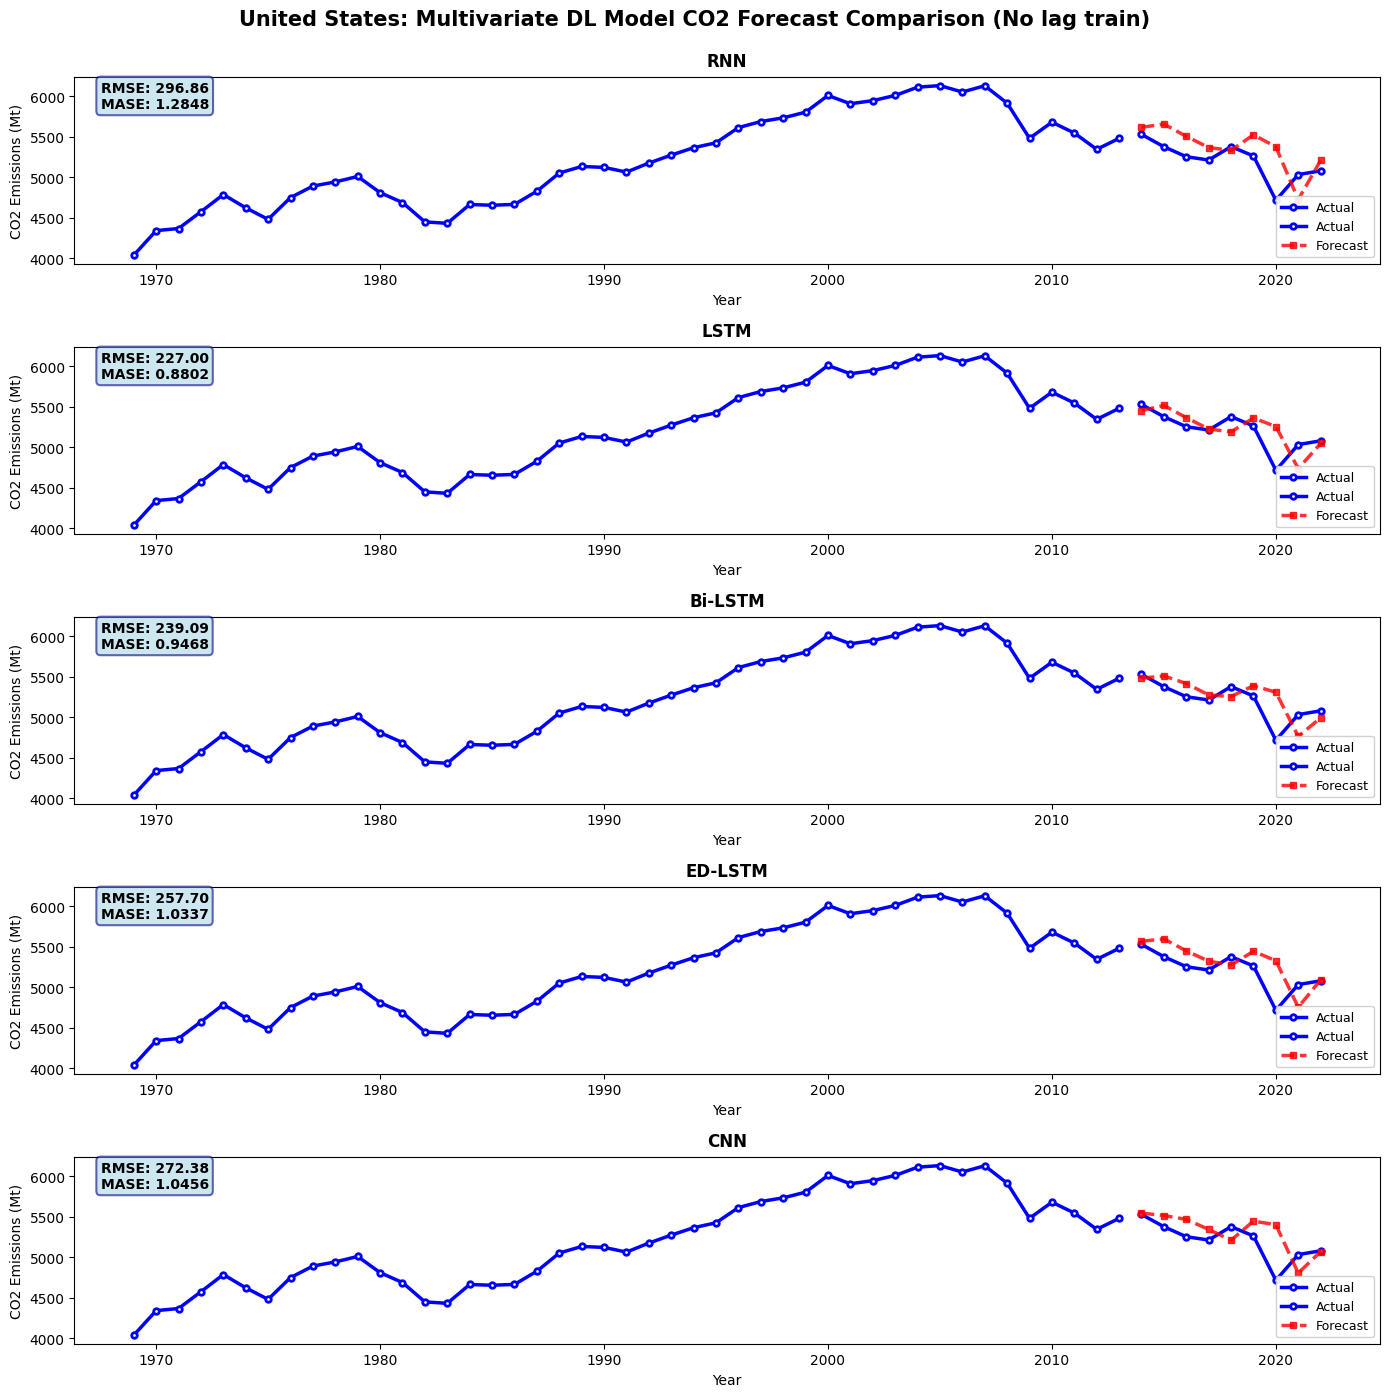

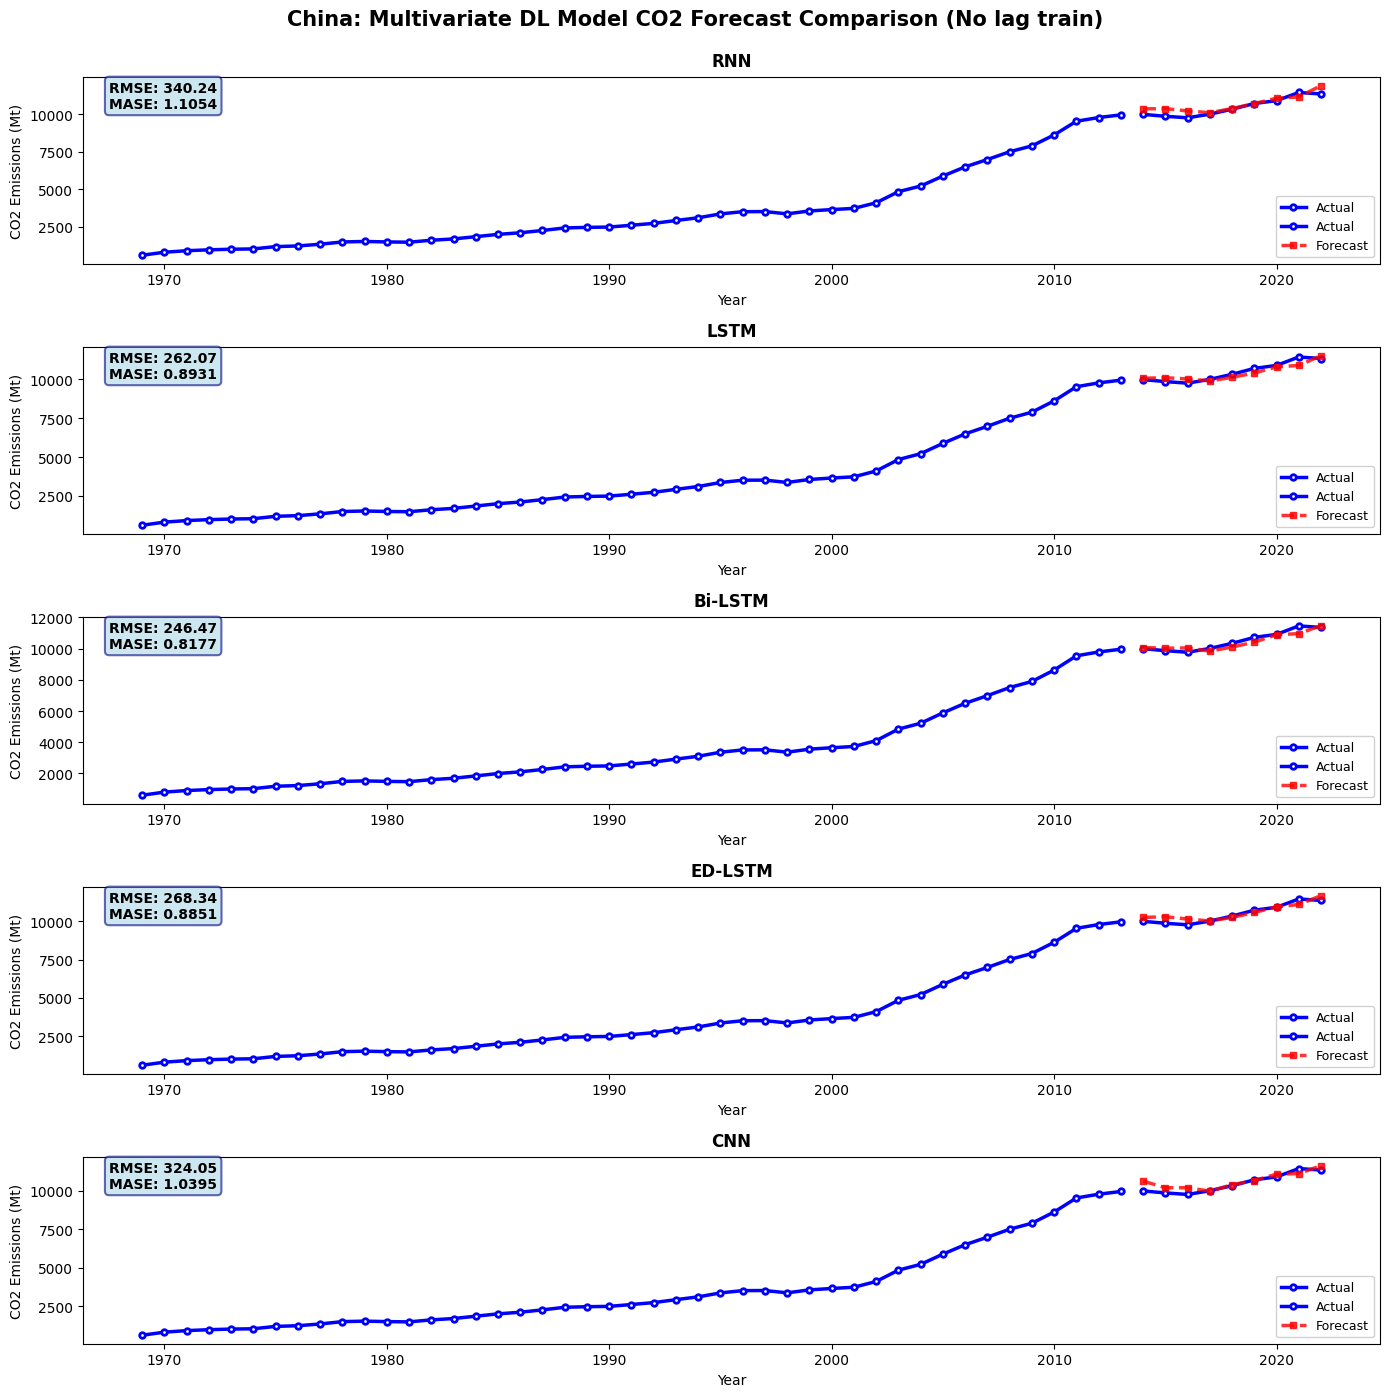

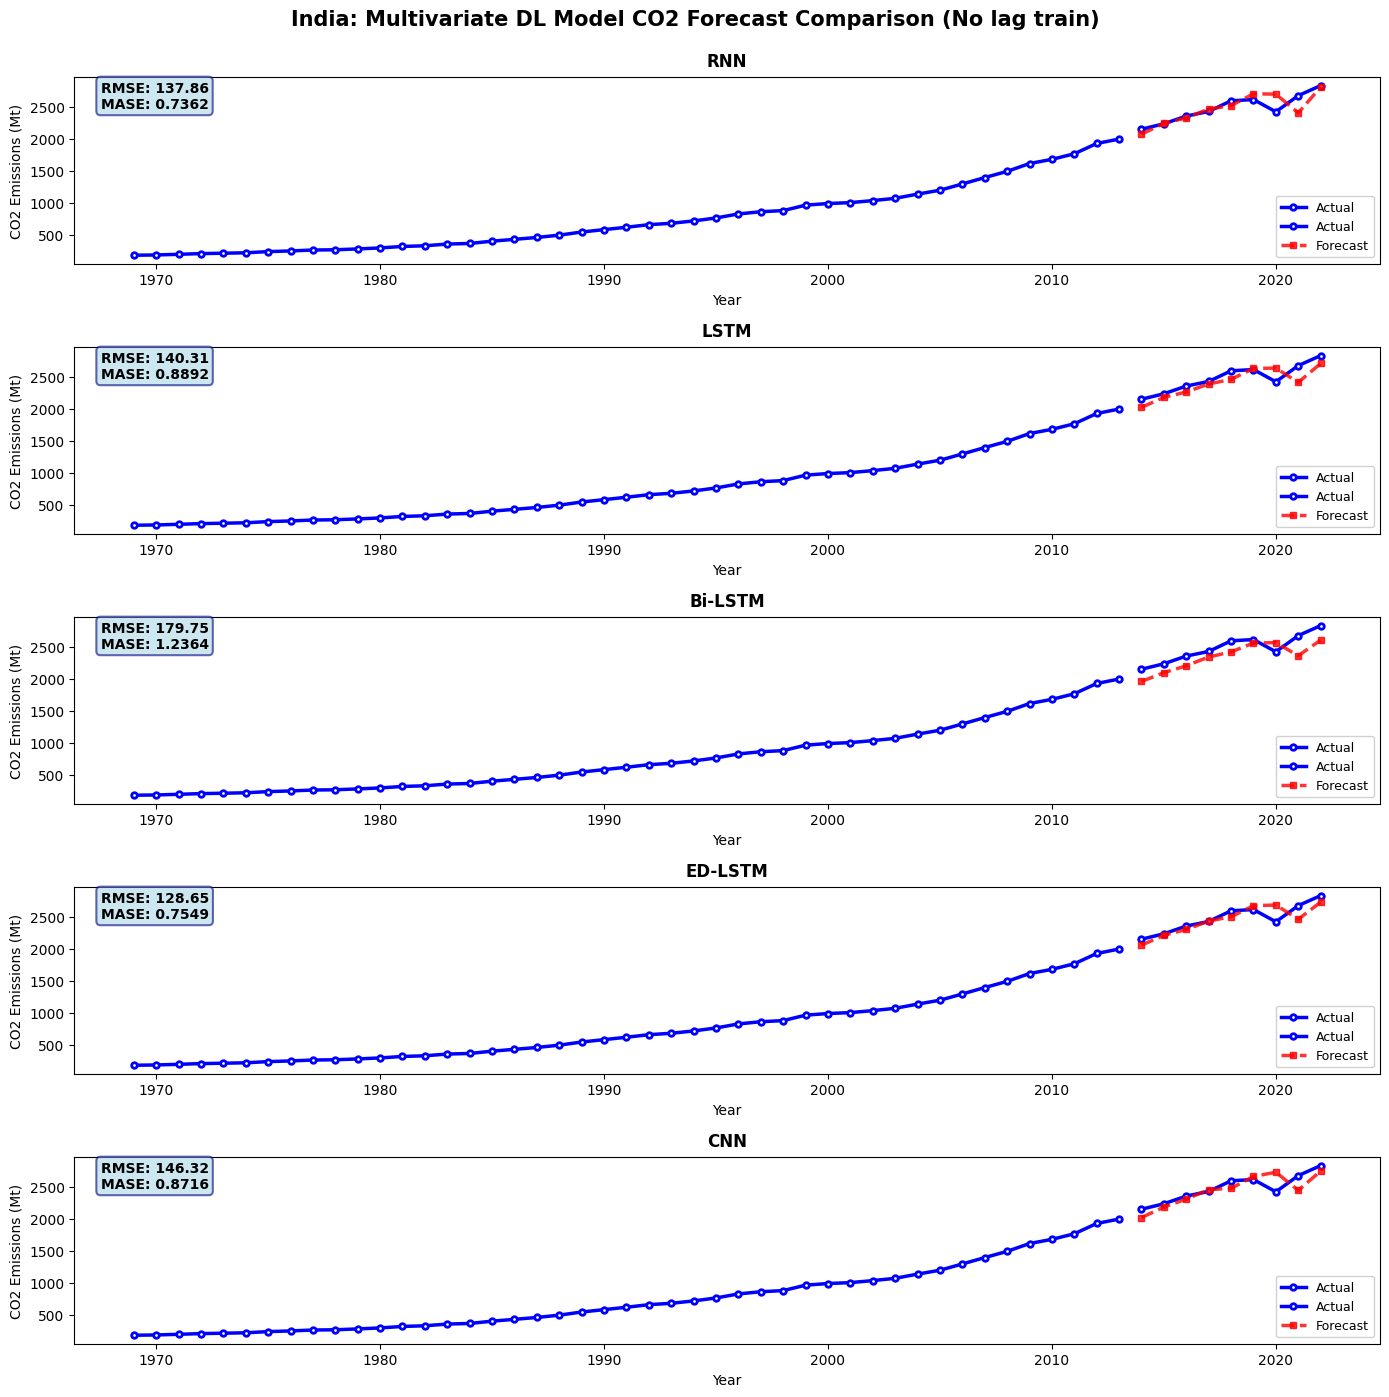

In [87]:
colors = {'actual': 'blue', 'forecast': 'red'}

for country in SELECTED_COUNTRIES:
    print(f"\nCreating plot for {country.upper()}")
     
    train_country = all_train_df[all_train_df['country'] == country].sort_values('year')
    test_country = all_test_df[all_test_df['country'] == country].sort_values('year')

    fig, axes = plt.subplots(5, 1, figsize=(14, 14))

    for idx, model_name in enumerate(DL_MODELS_ORDER):
        ax = axes[idx]

        # Plot train data
        ax.plot(train_country['year'], train_country[TARGET_VARIABLES], color=colors['actual'], linewidth=2.5,
                label='Actual', marker='o', markersize=4, markerfacecolor='white', markeredgewidth=2,
                markeredgecolor=colors['actual'])
        
        # Plot test actual data
        ax.plot(test_country['year'], test_country[TARGET_VARIABLES], color=colors['actual'], linewidth=2.5,
                label='Actual', marker='o', markersize=4, markerfacecolor='white', markeredgewidth=2,
                markeredgecolor=colors['actual'])
        
        # Plot forecast data
        if model_name in dl_results[country]:
            result = dl_results[country][model_name]
            forecast = result['forecast']
            rmse_score = result['RMSE']
            mase_score = result['MASE']
            test_years = result['test_years']

            ax.plot(test_years, forecast, color=colors['forecast'], linewidth=2.5,
                        linestyle='--', label='Forecast', marker='s', markersize=4, alpha=0.8)

            metrics_str = f"RMSE: {rmse_score:.2f}\nMASE: {mase_score:.4f}"
            props = dict(boxstyle='round', facecolor='lightblue', alpha=0.6, edgecolor='navy', linewidth=1.5)
            ax.text(0.02, 0.98, metrics_str, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                        bbox=props, fontweight='bold')
        else:
             print("    Forecast not found")
            
        ax.set_title(f'{model_name}', fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('CO2 Emissions (Mt)', fontsize=10)
        ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

    plt.suptitle(f'{country}: Multivariate DL Model CO2 Forecast Comparison (No lag train)', 
                fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()

    # Save
    plot_filename = f"{country.replace(' ', '_')}_multivariate_all_country_model_comparison.png"
    plot_filepath = os.path.join(save_dir, plot_filename)
    plt.savefig(plot_filepath, dpi=150, bbox_inches='tight')

### Comparison of G20 model of three-country target and all-country target

In [88]:
all_dl_results = eval_on_test(all_train_df, all_test_df, TARGET_VARIABLES, ALL_FEATURES, scaler, all_trained_models, all_countries)


AFGHANISTAN
Test sequence shape: (9, 5, 8)

  RNN
    RMSE: 0.7430
    MASE: 0.8874
    Config: {'hidden': 4, 'dropout': 0.2, 'lr': 0.005, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

  LSTM
    RMSE: 0.8902
    MASE: 0.9229
    Config: {'hidden': 16, 'dropout': 0.1, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

  Bi-LSTM
    RMSE: 0.7695
    MASE: 0.8948
    Config: {'hidden': 32, 'dropout': 0.0, 'lr': 0.0001, 'l2': 0.001, 'l2_recurrent': 0.001, 'batch_size': 16, 'epochs': 100}

  ED-LSTM
    RMSE: 0.7820
    MASE: 0.8210
    Config: {'hidden': 8, 'dropout': 0.2, 'lr': 0.001, 'l2': 0.001, 'batch_size': 16, 'epochs': 100}

  CNN
    RMSE: 0.7474
    MASE: 0.6409
    Config: {'filters': 16, 'lr': 0.0001, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

ALBANIA
Test sequence shape: (9, 5, 8)

  RNN
    RMSE: 0.5732
    MASE: 1.1883
    Config: {'hidden': 4, 'dropout': 0.2, 'lr': 0.005, 'l2': 0.001, 'batch_size': 32, 'epochs': 100}

  LSTM
    RMSE: 0.5999
    MASE: 1.2368

In [89]:
three_country_avg = {}

for model_name in DL_MODELS_ORDER:
    rmse_values = []
    mase_values = []
    
    for country in SELECTED_COUNTRIES:
        if model_name in dl_results[country]:
            rmse_values.append(dl_results[country][model_name]['RMSE'])
            mase_values.append(dl_results[country][model_name]['MASE'])
    
    three_country_avg[model_name] = {
        'avg_rmse': np.mean(rmse_values),
        'avg_mase': np.mean(mase_values)
    }

In [90]:
all_country_avg = {}

for model_name in DL_MODELS_ORDER:
    rmse_values = []
    mase_values = []
    
    for country in all_countries:
        if model_name in all_dl_results[country]:
            rmse_values.append(all_dl_results[country][model_name]['RMSE'])
            mase_values.append(all_dl_results[country][model_name]['MASE'])
    
    all_country_avg[model_name] = {
        'avg_rmse': np.mean(rmse_values),
        'avg_mase': np.mean(mase_values)
    }

In [91]:
comparison_data = []

for model_name in DL_MODELS_ORDER:
    comparison_data.append({
        'Model': model_name,
        'Avg_RMSE_Three_Countries': three_country_avg[model_name]['avg_rmse'],
        'Avg_MASE_Three_Countries': three_country_avg[model_name]['avg_mase'],
        'Avg_RMSE_all': all_country_avg[model_name]['avg_rmse'],
        'Avg_MASE_all': all_country_avg[model_name]['avg_mase']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

In [92]:
comparison_filepath = os.path.join(save_dir, 'model_comparison_three_vs_all.md')

with open(comparison_filepath, 'w') as f:
    f.write("# Model Performance Comparison: Target as Three Countries vs All Countries\n\n")
    f.write("- **Training Data**: All countries excluded regions and countries under 0.8 data coverage\n")
    f.write("## Average Performance Metrics\n\n")
    f.write("| Model | Avg RMSE (3 Countries) | Avg MASE (3 Countries) | Avg RMSE (All) | Avg MASE (All) |\n")
    f.write("|-------|------------------------|------------------------|----------------|----------------|\n")
    for _, row in comparison_df.iterrows():
        f.write(f"| {row['Model']} | {row['Avg_RMSE_Three_Countries']:.4f} | {row['Avg_MASE_Three_Countries']:.4f} | ")
        f.write(f"{row['Avg_RMSE_all']:.4f} | {row['Avg_MASE_all']:.4f} |\n")